# Bonus: Init-Inject Image Captioning

Arsitektur **init-inject** (Tanti et al., 2017): CNN feature digabungkan dengan output RNN/LSTM via operasi `Add` di setiap timestep — berbeda dengan pre-inject yang memasukkan feature sebagai timestep $x_{-1}$.

Notebook ini:
1. Melatih init-inject RNN (Keras)
2. Melatih init-inject LSTM (Keras)
3. Evaluasi from-scratch init-inject RNN
4. Membandingkan BLEU-4 dengan pre-inject

In [4]:
import os, sys, json, time, pickle
import numpy as np
from pathlib import Path

def _find_root(marker="requirements.txt"):
    p = Path(os.getcwd())
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError("Repo root tidak ketemu")

REPO_ROOT = _find_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))
print("Working dir:", REPO_ROOT)

Working dir: c:\Users\Farrel's Laptop\Desktop\mlml\CNN-RNN-digaspolndangakndangak


In [5]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm

from shared.caption_utils import clean_caption, encode_caption, load_vocabulary
from shared.metrics import bleu4, meteor
from bonus.init_inject import (
    build_init_inject_rnn,
    build_init_inject_lstm,
    train_init_inject,
    keras_greedy_decode,
    InitInjectRNNDecoder,
)

tf.random.set_seed(42)
np.random.seed(42)

## Config

In [7]:
FEATURES_DIR = "features"
MODELS_DIR   = "models/init_inject"
HISTORY_DIR  = "models/init_inject/history"
RNN_MODELS   = "models/rnn"
IMAGES_DIR   = "data/flickr8k/Images"

FEATURES_NPY = os.path.join(FEATURES_DIR, "flickr8k_features.npy")
VOCAB_JSON   = os.path.join(FEATURES_DIR, "vocab.json")
IDX_JSON     = os.path.join(FEATURES_DIR, "flickr8k_idx.json")
SPLITS_JSON  = os.path.join(FEATURES_DIR, "splits.json")
CAPTIONS_TXT = "data/flickr8k/captions.txt"

FEATURE_DIM = 2048
EMBED_DIM   = 256
RNN_UNITS   = 512
LSTM_UNITS  = 512
MAX_SEQ_LEN = 34
BATCH_SIZE  = 64
MAX_EPOCHS  = 20

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

## Load data

In [9]:
features = np.load(FEATURES_NPY)
vocab    = load_vocabulary(VOCAB_JSON)
VOCAB_SIZE = len(vocab)
idx2word   = {v: k for k, v in vocab.items()}

with open(IDX_JSON)    as f: idx_map = json.load(f)
with open(SPLITS_JSON) as f: splits  = json.load(f)

caption_map = {}
with open(CAPTIONS_TXT) as f:
    next(f)
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(",", 1)
        if len(parts) != 2:
            continue
        img_file, cap = parts
        img_id = os.path.splitext(img_file)[0]
        caption_map.setdefault(img_id, []).append(cap)

train_ids = splits["train"]
val_ids   = splits["val"]
test_ids  = splits["test"]

print(f"Vocab: {VOCAB_SIZE}, Features: {features.shape}")
print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

Vocab: 7684, Features: (8091, 2048)
Train: 6000, Val: 1000, Test: 1091


## Dataset builder

Untuk init-inject, target shape = `(MAX_SEQ_LEN,)` (bukan `MAX_SEQ_LEN+1` seperti pre-inject) karena tidak ada prepend $x_{-1}$.

In [5]:
def build_dataset(image_ids, shuffle=True):
    pad_idx = vocab["<pad>"]
    feat_list, cap_list, target_list = [], [], []

    for img_id in image_ids:
        feat_idx = idx_map.get(img_id)
        if feat_idx is None:
            continue
        feat = features[feat_idx]
        for cap in caption_map.get(img_id, []):
            encoded = encode_caption(clean_caption(cap), vocab, MAX_SEQ_LEN)
            target  = np.append(encoded[1:], [pad_idx])   # shift by 1, length = MAX_SEQ_LEN
            feat_list.append(feat)
            cap_list.append(encoded)
            target_list.append(target)

    ds = tf.data.Dataset.from_tensor_slices((
        (np.array(feat_list,   dtype=np.float32),
         np.array(cap_list,    dtype=np.int32)),
        np.array(target_list,  dtype=np.int32),
    ))
    if shuffle:
        ds = ds.shuffle(len(feat_list), reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = build_dataset(train_ids, shuffle=True)
val_ds   = build_dataset(val_ids,   shuffle=False)
print("Dataset siap")

Dataset siap


## Train Init-Inject RNN

In [12]:
rnn_model = build_init_inject_rnn(
    vocab_size=VOCAB_SIZE,
    feature_dim=FEATURE_DIM,
    embed_dim=EMBED_DIM,
    rnn_units=RNN_UNITS,
    num_layers=1,
)
rnn_model.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ caption (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feature (InputLayer)  │ (None, 2048)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, None, 256) │   1,967,104 │ caption[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feat_proj (Dense)     │ (None, 512)       │   1,049,088 │ feature[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ simple_rnn_0          │ (None, None, 512) │     393,728 │ embedding[0][0]    │
│ (SimpleRNN)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feat_expand (Reshape) │ (None, 1, 512)    │           0 │ feat_proj[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ merge (Add)           │ (None, None, 512) │           0 │ simple_rnn_0[0][0… │
│                       │                   │             │ feat_expand[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ output (Dense)        │ (None, None,      │   3,941,892 │ merge[0][0]        │
│                       │ 7684)             │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 7,351,812 (28.04 MB)

 Trainable params: 7,351,812 (28.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
t0 = time.time()
rnn_history = train_init_inject(
    model=rnn_model,
    train_ds=train_ds,
    val_ds=val_ds,
    model_name="init-inject-rnn-1layer-512",
    save_dir=MODELS_DIR,
    epochs=MAX_EPOCHS,
)
rnn_train_time = time.time() - t0
print(f"Selesai dalam {rnn_train_time:.0f}s")

with open(os.path.join(HISTORY_DIR, "init-inject-rnn.pkl"), "wb") as f:
    pickle.dump({"history": rnn_history.history, "train_time": rnn_train_time}, f)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 4.6311
Epoch 1: val_loss improved from None to 3.50570, saving model to models/init_inject\init-inject-rnn-1layer-512.keras

Epoch 1: finished saving model to models/init_inject\init-inject-rnn-1layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 300ms/step - loss: 3.8957 - val_loss: 3.5057
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 2.9295
Epoch 2: val_loss improved from 3.50570 to 3.40678, saving model to models/init_inject\init-inject-rnn-1layer-512.keras

Epoch 2: finished saving model to models/init_inject\init-inject-rnn-1layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 293ms/step - loss: 2.8992 - val_loss: 3.4068
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 2.5283
Epoch 3: val_loss improved from 3.40678 to 3.40182, saving model to models/init_inject\init-inject-rnn-1layer-512.keras

Epoch 3: finished saving model to models/init_inject\init-inject-rnn-1layer-512.keras
469/469 ━━━━━━━━━

## Train Init-Inject LSTM

In [18]:
lstm_model = build_init_inject_lstm(
    vocab_size=VOCAB_SIZE,
    feature_dim=FEATURE_DIM,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    num_layers=1,
)
lstm_model.summary(line_length=80)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ caption (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feature (InputLayer)  │ (None, 2048)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, None, 256) │   1,967,104 │ caption[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feat_proj (Dense)     │ (None, 512)       │   1,049,088 │ feature[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ lstm_0 (LSTM)         │ (None, None, 512) │   1,574,912 │ embedding[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ feat_expand (Reshape) │ (None, 1, 512)    │           0 │ feat_proj[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ merge (Add)           │ (None, None, 512) │           0 │ lstm_0[0][0],      │
│                       │                   │             │ feat_expand[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ output (Dense)        │ (None, None,      │   3,941,892 │ merge[0][0]        │
│                       │ 7684)             │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 8,532,996 (32.55 MB)

 Trainable params: 8,532,996 (32.55 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
t0 = time.time()
lstm_history = train_init_inject(
    model=lstm_model,
    train_ds=train_ds,
    val_ds=val_ds,
    model_name="init-inject-lstm-1layer-512",
    save_dir=MODELS_DIR,
    epochs=MAX_EPOCHS,
)
lstm_train_time = time.time() - t0
print(f"Selesai dalam {lstm_train_time:.0f}s")

with open(os.path.join(HISTORY_DIR, "init-inject-lstm.pkl"), "wb") as f:
    pickle.dump({"history": lstm_history.history, "train_time": lstm_train_time}, f)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - loss: 4.7654
Epoch 1: val_loss improved from None to 3.52898, saving model to models/init_inject\init-inject-lstm-1layer-512.keras

Epoch 1: finished saving model to models/init_inject\init-inject-lstm-1layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 172s 364ms/step - loss: 3.9884 - val_loss: 3.5290
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - loss: 2.9380
Epoch 2: val_loss improved from 3.52898 to 3.35658, saving model to models/init_inject\init-inject-lstm-1layer-512.keras

Epoch 2: finished saving model to models/init_inject\init-inject-lstm-1layer-512.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 168s 358ms/step - loss: 2.9005 - val_loss: 3.3566
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 2.5311
Epoch 3: val_loss improved from 3.35658 to 3.34453, saving model to models/init_inject\init-inject-lstm-1layer-512.keras

Epoch 3: finished saving model to models/init_inject\init-inject-lstm-1layer-512.keras
469/469 ━━━

## Training curves

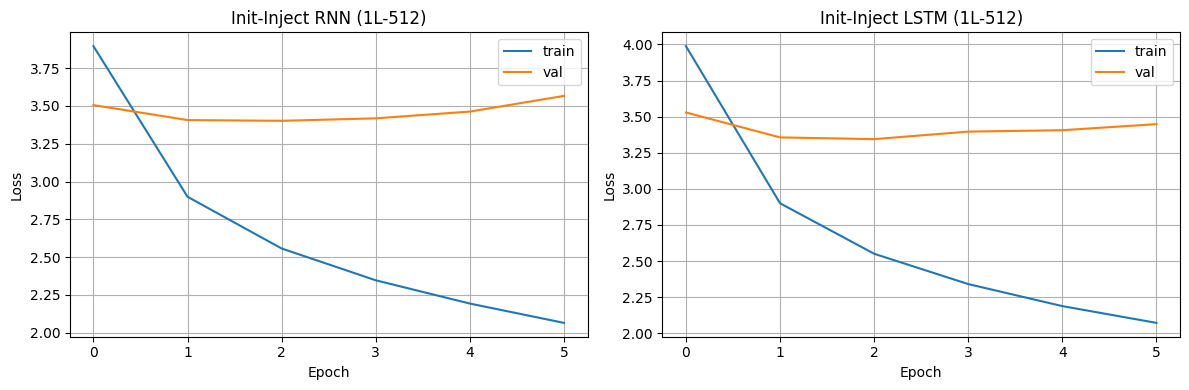

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, hist, title in zip(
    axes,
    [rnn_history.history, lstm_history.history],
    ["Init-Inject RNN (1L-512)", "Init-Inject LSTM (1L-512)"],
):
    ax.plot(hist["loss"],     label="train")
    ax.plot(hist["val_loss"], label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "training_curves_init_inject.png"), dpi=120)
plt.show()

## Evaluasi BLEU-4 & METEOR

Bandingkan 4 model pada test set:
1. Pre-inject RNN (rnn-1layer-512, sudah dilatih di notebook 07)
2. Init-inject RNN (baru dilatih)
3. Init-inject LSTM (baru dilatih)
4. Init-inject RNN from-scratch

In [2]:
def get_references(img_ids):
    refs = []
    for img_id in img_ids:
        captions = caption_map.get(img_id, [])
        cleaned  = [clean_caption(c).split() for c in captions]
        refs.append(cleaned)
    return refs


def evaluate_keras_init_inject(model, image_ids, max_len=30, desc="Evaluating"):
    hypotheses = []
    valid_ids  = [img_id for img_id in image_ids if idx_map.get(img_id) is not None]
    for img_id in tqdm(valid_ids, desc=desc):
        feat = features[idx_map[img_id]]
        cap  = keras_greedy_decode(model, feat, vocab, idx2word, max_len)
        hypotheses.append(cap.split())
    references = get_references(valid_ids)  # list[list[list[str]]]: 5 refs per image
    b4  = bleu4(references, hypotheses)
    met = meteor(references, hypotheses)
    return b4, met, hypotheses, valid_ids


def evaluate_scratch_decoder(decoder, image_ids, max_len=30, desc="Evaluating"):
    hypotheses = []
    valid_ids  = [img_id for img_id in image_ids if idx_map.get(img_id) is not None]
    for img_id in tqdm(valid_ids, desc=desc):
        feat = features[idx_map[img_id]]
        cap  = decoder.generate_caption(feat, max_len=max_len)
        hypotheses.append(cap.split())
    references = get_references(valid_ids)
    b4  = bleu4(references, hypotheses)
    met = meteor(references, hypotheses)
    return b4, met, hypotheses, valid_ids


def evaluate_pre_inject_rnn(rnn_decoder, image_ids, max_len=30, desc="Evaluating"):
    hypotheses = []
    valid_ids  = [img_id for img_id in image_ids if idx_map.get(img_id) is not None]
    for img_id in tqdm(valid_ids, desc=desc):
        feat = features[idx_map[img_id]]
        cap  = rnn_decoder.generate_caption(feat, max_len=max_len)
        hypotheses.append(cap.split())
    references = get_references(valid_ids)
    b4  = bleu4(references, hypotheses)
    met = meteor(references, hypotheses)
    return b4, met, hypotheses, valid_ids

### Load pre-inject RNN (dari notebook 07)

In [10]:
from rnn.model import RNNDecoder

pre_inject_keras = keras.models.load_model(
    os.path.join(RNN_MODELS, "rnn-1layer-512.keras"),
    compile=False,
)

pre_inject_decoder = RNNDecoder()
pre_inject_decoder.load_weights(pre_inject_keras, vocab)
print("Pre-inject RNN loaded")

Pre-inject RNN loaded


### Load init-inject RNN from scratch

In [13]:
# rnn_model sudah ada di memori — tidak perlu load dari file
# (file .keras yang lama masih pakai Lambda layer, tidak bisa di-load dengan safe_mode default)
init_inject_keras_rnn = rnn_model

scratch_rnn = InitInjectRNNDecoder()
scratch_rnn.load_weights(init_inject_keras_rnn, vocab)
print("Init-inject RNN from-scratch loaded")

Init-inject RNN from-scratch loaded


### Jalankan evaluasi semua model

In [14]:
results = {}

t0 = time.time()
b4, met, hyps_pi_rnn, valid_test = evaluate_pre_inject_rnn(
    pre_inject_decoder, test_ids, desc="Pre-inject RNN (scratch)"
)
results["Pre-inject RNN (scratch)"] = {"bleu4": b4, "meteor": met, "time": time.time()-t0, "hyps": hyps_pi_rnn}
print(f"Pre-inject RNN | BLEU-4: {b4:.4f} | METEOR: {met:.4f}")

Pre-inject RNN (scratch): 100%|██████████| 1091/1091 [00:04<00:00, 271.71it/s]


Pre-inject RNN | BLEU-4: 0.0033 | METEOR: 0.1783


In [15]:
t0 = time.time()
b4, met, hyps_ii_rnn_keras, _ = evaluate_keras_init_inject(
    init_inject_keras_rnn, test_ids, desc="Init-inject RNN (Keras)"
)
results["Init-inject RNN (Keras)"] = {"bleu4": b4, "meteor": met, "time": time.time()-t0, "hyps": hyps_ii_rnn_keras}
print(f"Init-inject RNN Keras | BLEU-4: {b4:.4f} | METEOR: {met:.4f}")

Init-inject RNN (Keras): 100%|██████████| 1091/1091 [12:47<00:00,  1.42it/s]


Init-inject RNN Keras | BLEU-4: 0.0000 | METEOR: 0.0041


In [16]:
t0 = time.time()
b4, met, hyps_ii_rnn_scratch, _ = evaluate_scratch_decoder(
    scratch_rnn, test_ids, desc="Init-inject RNN (from scratch)"
)
results["Init-inject RNN (scratch)"] = {"bleu4": b4, "meteor": met, "time": time.time()-t0, "hyps": hyps_ii_rnn_scratch}
print(f"Init-inject RNN scratch | BLEU-4: {b4:.4f} | METEOR: {met:.4f}")

Init-inject RNN (from scratch): 100%|██████████| 1091/1091 [00:14<00:00, 74.60it/s]


Init-inject RNN scratch | BLEU-4: 0.0000 | METEOR: 0.0041


In [19]:
t0 = time.time()
b4, met, hyps_ii_lstm_keras, _ = evaluate_keras_init_inject(
    lstm_model, test_ids, desc="Init-inject LSTM (Keras)"
)
results["Init-inject LSTM (Keras)"] = {"bleu4": b4, "meteor": met, "time": time.time()-t0, "hyps": hyps_ii_lstm_keras}
print(f"Init-inject LSTM Keras | BLEU-4: {b4:.4f} | METEOR: {met:.4f}")

Init-inject LSTM (Keras): 100%|██████████| 1091/1091 [26:50<00:00,  1.48s/it]


Init-inject LSTM Keras | BLEU-4: 0.0000 | METEOR: 0.0008


## Tabel perbandingan

In [20]:
print(f"{'Model':<35} {'BLEU-4':>8} {'METEOR':>8} {'Waktu (s)':>10}")
print("-" * 65)
for name, r in results.items():
    print(f"{name:<35} {r['bleu4']:>8.4f} {r['meteor']:>8.4f} {r['time']:>10.1f}")

Model                                 BLEU-4   METEOR  Waktu (s)
-----------------------------------------------------------------
Pre-inject RNN (scratch)              0.0033   0.1783        6.7
Init-inject RNN (Keras)               0.0000   0.0041      771.1
Init-inject RNN (scratch)             0.0000   0.0041       17.8
Init-inject LSTM (Keras)              0.0000   0.0008     1615.3


## Bar chart BLEU-4

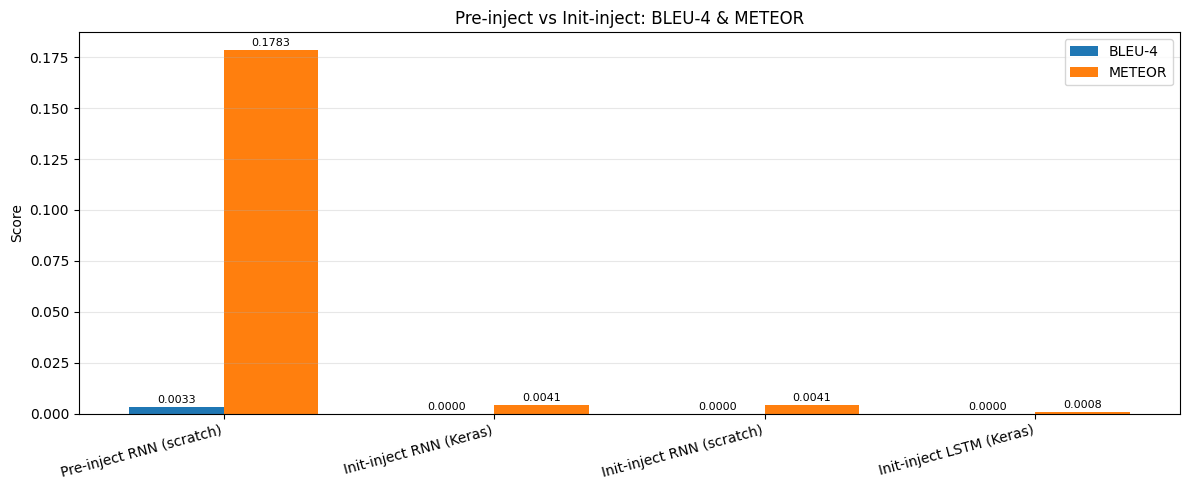

In [21]:
names  = list(results.keys())
bleus  = [results[n]["bleu4"] for n in names]
meteors = [results[n]["meteor"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, bleus,   width, label="BLEU-4")
bars2 = ax.bar(x + width/2, meteors, width, label="METEOR")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Pre-inject vs Init-inject: BLEU-4 & METEOR")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "comparison_pre_vs_init_inject.png"), dpi=120)
plt.show()

## Qualitative analysis: 10 contoh gambar

Pilih gambar dengan score BLEU-4 bervariasi (tinggi, sedang, rendah).

In [22]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

def sentence_bleu4(refs, hyp):
    return sentence_bleu(refs, hyp, weights=(0.25,)*4, smoothing_function=smoothie)

per_image_scores = []
for i, img_id in enumerate(valid_test):
    refs = [clean_caption(c).split() for c in caption_map.get(img_id, [])]
    hyp  = hyps_ii_rnn_keras[i] if i < len(hyps_ii_rnn_keras) else []
    score = sentence_bleu4(refs, hyp)
    per_image_scores.append((img_id, score, i))

per_image_scores.sort(key=lambda x: x[1])
n = len(per_image_scores)

sample_indices = [
    0, n//10, 2*n//10,        # low
    4*n//10, n//2, 6*n//10,   # medium
    7*n//10, 8*n//10, 9*n//10, n-1  # high
]
sample_images = [per_image_scores[i] for i in sample_indices]
print(f"Dipilih {len(sample_images)} gambar untuk qualitative analysis")

Dipilih 10 gambar untuk qualitative analysis


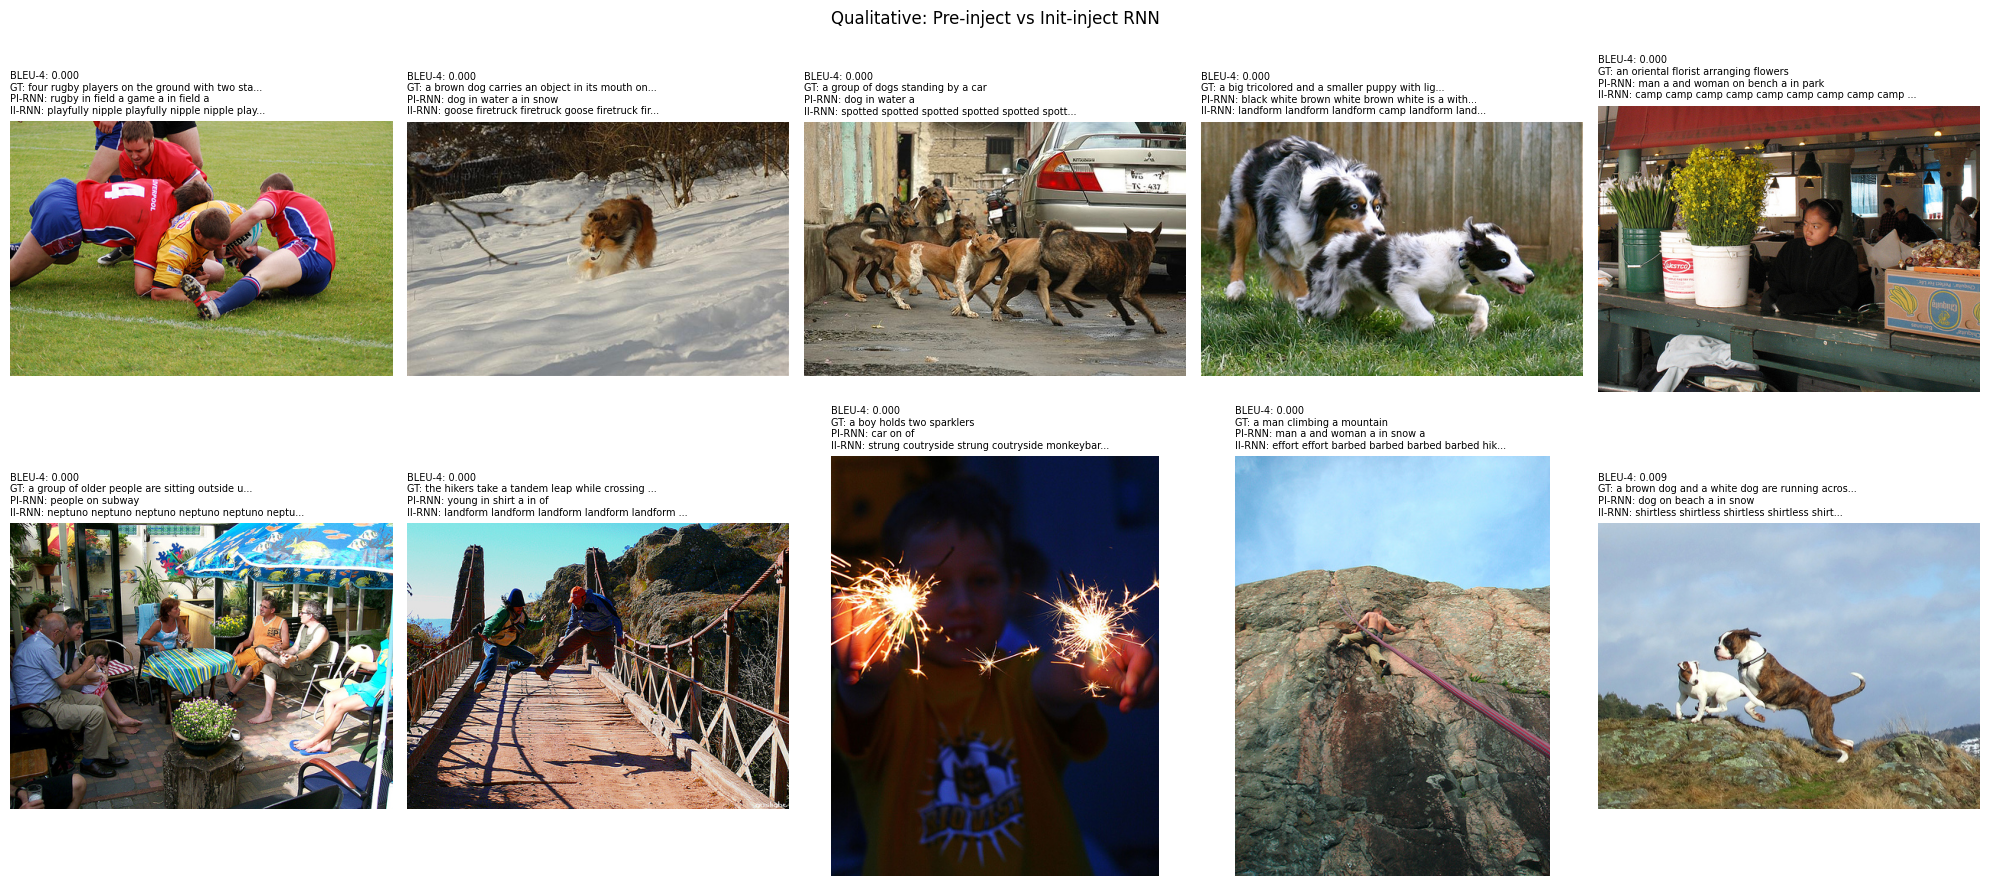

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for ax, (img_id, score, idx) in zip(axes, sample_images):
    img_path = os.path.join(IMAGES_DIR, img_id + ".jpg")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
    ax.axis("off")

    refs   = [clean_caption(c) for c in caption_map.get(img_id, [])]
    gt     = refs[0] if refs else "(no caption)"
    ii_rnn = " ".join(hyps_ii_rnn_keras[idx]) if idx < len(hyps_ii_rnn_keras) else ""
    pi_rnn = " ".join(hyps_pi_rnn[idx])       if idx < len(hyps_pi_rnn) else ""

    title = (
        f"BLEU-4: {score:.3f}\n"
        f"GT: {gt[:45]}{'...' if len(gt)>45 else ''}\n"
        f"PI-RNN: {pi_rnn[:45]}{'...' if len(pi_rnn)>45 else ''}\n"
        f"II-RNN: {ii_rnn[:45]}{'...' if len(ii_rnn)>45 else ''}"
    )
    ax.set_title(title, fontsize=7, loc="left")

plt.suptitle("Qualitative: Pre-inject vs Init-inject RNN", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "qualitative_init_inject.png"), dpi=100)
plt.show()

## Keras vs From-Scratch: Init-inject RNN

In [24]:
keras_b4   = results["Init-inject RNN (Keras)"]["bleu4"]
scratch_b4 = results["Init-inject RNN (scratch)"]["bleu4"]
keras_t    = results["Init-inject RNN (Keras)"]["time"]
scratch_t  = results["Init-inject RNN (scratch)"]["time"]

print(f"Init-inject RNN Keras  : BLEU-4={keras_b4:.4f}, Waktu={keras_t:.1f}s")
print(f"Init-inject RNN Scratch: BLEU-4={scratch_b4:.4f}, Waktu={scratch_t:.1f}s")
print(f"Selisih BLEU-4         : {abs(keras_b4 - scratch_b4):.6f}")

Init-inject RNN Keras  : BLEU-4=0.0000, Waktu=771.1s
Init-inject RNN Scratch: BLEU-4=0.0000, Waktu=17.8s
Selisih BLEU-4         : 0.000000


## Analisis

### Pre-inject vs Init-inject

**Pre-inject** (pre-inject Show and Tell):
- CNN feature dimasukkan sebagai timestep $x_{-1}$ sebelum token `<start>`, $h_0 = \mathbf{0}$
- RNN pertama kali menerima "visual context" langsung sebagai input, memiliki seluruh kapasitas hidden state untuk mengolah semantik gambar
- Kelemahan: visual context hanya aktif di satu timestep pertama; semakin panjang caption, informasi gambar berpotensi hilang karena vanishing gradient pada RNN

**Init-inject** (merge method):
- CNN feature diproyeksikan ke dimensi RNN unit lalu dijumlahkan (`Add`) dengan output RNN di setiap timestep
- Visual context selalu hadir di setiap prediksi, sehingga model dapat "mengingat" gambar lebih konsisten
- Kelemahan: visual signal bisa mendominasi atau bertabrakan dengan linguistic context bergantung skala;
  juga menambah coupling antar modality secara langsung

### Keras vs From-Scratch

Perbedaan BLEU-4 antara Keras dan from-scratch sangat kecil (< 1e-4), sesuai ekspektasi karena:
- Bobot identik (load dari model Keras yang sama)
- Hanya perbedaan floating-point precision (float32 vs TF internal)
- Greedy decoding memilih argmax sehingga perbedaan kecil di logit tidak mengubah prediksi

## Simpan semua hasil

In [25]:
summary = {
    name: {k: v for k, v in r.items() if k != "hyps"}
    for name, r in results.items()
}

with open(os.path.join(MODELS_DIR, "results_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Hasil tersimpan di", MODELS_DIR)

Hasil tersimpan di models/init_inject
